In [1]:
using GLMakie, OrdinaryDiffEq, LinearAlgebra, UnPack, LaTeXStrings, Random, NBInclude
@nbinclude("../../../set_makie_defaults.ipynb")

In [2]:
function phase_portrait(f::Function; limits::NTuple{4,T}, p = nothing, size::Tuple = (400,400), 
                        nx::Int = 20, ny::Int = 20, linewidth::Number, tspan::Tuple) where T
    """
    Plot the phase portrait of a two-dimensional ODE system du/dt = f(u), where f = (f₁, f₂) is a vector field. 

    TODO:
    - Draw arrows, evenly spaced w.r.t. arc length 
    - Option to avoid drawing arrows when trajectories are close together
    - 

    
   
    ARGUMENTS
    ---------
    f :: the vector field (a function from R^2 to R^2)
    limits :: the x- and y-limits of the plot, given as a tuple (xmin, xmax, ymin, ymax)
    p :: optional parameter for f

    nx :: number of distinct x-values for the initial conditions
    ny :: number of distinct y-values for the initial conditions 

    RETURNS
    -------
    """

    fig = Figure(size = size)
    ax = Axis(fig[1,1], xlabel = L"x", ylabel = L"y", title = L"\textrm{Phase Portrait}", limits = limits)

    xmin, xmax, ymin, ymax = limits 
 
    #Get a uniform sample of initial conditions 
    x0s = LinRange(xmin, xmax, nx)
    y0s = LinRange(ymin, ymax, ny)
    u0s = vec([[x0, y0] for x0 in x0s, y0 in y0s])
 
    for u0 in u0s  
        prob = ODEProblem(f, u0, tspan, p)
        sol = solve(prob, ImplicitEuler(), abstol = 1e-6, reltol = 1e-2) 
        us = sol.u
        xs = getindex.(us, 1)
        ys = getindex.(us, 2)
        lines!(ax, xs, ys, linewidth = linewidth, color = :blue) 
    end

  
    return fig
    
end 

phase_portrait (generic function with 1 method)

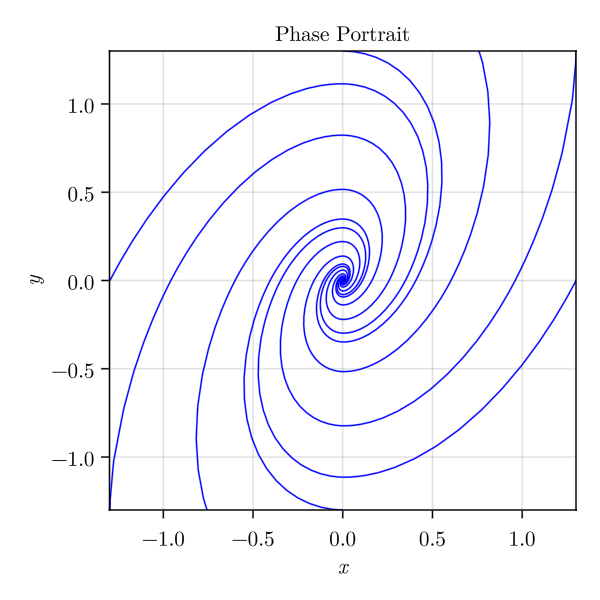

In [61]:
function f(u,p,t)
    a = -1.0 
    b = 1.0
    c = -2.0
    d = 0.0
    return [a*u[1] + b*u[2], c*u[1] + d*u[2]]
end 


fig = phase_portrait(f; limits = (-1.3,1.3,-1.3,1.3), nx = 3, ny = 3, linewidth = 1, tspan = (-200,200))

In [23]:
a = [1,2,3]
b = [4,5,6]

c = vec([[x,y] for x in a, y in b])

9-element Vector{Vector{Int64}}:
 [1, 4]
 [2, 4]
 [3, 4]
 [1, 5]
 [2, 5]
 [3, 5]
 [1, 6]
 [2, 6]
 [3, 6]

In [14]:
?LinRange

search: LinRange Base.LogRange UnitRange OrdinalRange StepRange ytickrange range



```
LinRange{T,L}
```

A range with `len` linearly spaced elements between its `start` and `stop`. The size of the spacing is controlled by `len`, which must be an `Integer`.

# Examples

```jldoctest
julia> LinRange(1.5, 5.5, 9)
9-element LinRange{Float64, Int64}:
 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5
```

Compared to using [`range`](@ref), directly constructing a `LinRange` should have less overhead but won't try to correct for floating point errors:

```jldoctest
julia> collect(range(-0.1, 0.3, length=5))
5-element Vector{Float64}:
 -0.1
  0.0
  0.1
  0.2
  0.3

julia> collect(LinRange(-0.1, 0.3, 5))
5-element Vector{Float64}:
 -0.1
 -1.3877787807814457e-17
  0.09999999999999999
  0.19999999999999998
  0.3
```

See also [`Logrange`](@ref Base.LogRange) for logarithmically spaced points.
